# LSTM gate inspection (Keras custom LSTMCell)

In [1]:
# --------------------------------------------------------------
# 3️⃣  LSTM gate inspection (Keras custom LSTMCell)
# --------------------------------------------------------------
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras

In [ ]:
# --------------------------------------------------------------
# Define a cell that returns gate values
# --------------------------------------------------------------
class VerboseLSTMCell(keras.layers.LSTMCell):
    """
    Sub‑class of LSTMCell that exposes gate activations.

    The `call()` method returns (output, [h, c, gates]) where
        * output = h_next (the hidden state that the RNN layer uses)
        * h, c   = the new hidden / cell states
        * gates  = Tensor of shape (batch, 4, units) containing
                   [input_gate, forget_gate, output_gate, candidate]
    * `state_size` is overridden so that the wrapper knows the cell
      carries three states (h, c, gates).
    """

    # Tell the RNN wrapper that we have three states:
    #   h : units
    #   c : units
    #   gates : 4 * units   (flattened)
    def __init__(self, units, **kwargs):
        super().__init__(units, **kwargs)
        # Important: the order must match what we return in call()
        self.state_size = [units, units, 4 * units]

    def call(self, inputs, states, training=None):
        # Standard LSTM computation (identical to the parent class)
        h, c, _ = states  # each: (batch, units)

        # Linear part: concat(input, h) @ kernel + bias
        z = inputs @ self.kernel + h @ self.recurrent_kernel + self.bias

        # Split into pre‑activations for i, f, o, g
        i, f, o, g = tf.split(z, num_or_size_splits=4, axis=1)

        # Activations
        i = keras.activations.sigmoid(i)  # input gate
        f = keras.activations.sigmoid(f)  # forget gate
        o = keras.activations.sigmoid(o)  # output gate
        g = keras.activations.tanh(g)  # candidate

        # New states
        c_next = f * c + i * g
        h_next = o * keras.activations.tanh(c_next)

        # Pack the four gates - shape (batch, 4, units)
        gates = tf.stack([i, f, o, g], axis=1)

        # Flatten to (batch, 4*units) because `state_size` expects a vector
        gates_flat = tf.reshape(gates, [-1, 4 * self.units])

        # Return hidden output and the three states (h, c, gates_flat)
        return h_next, [h_next, c_next, gates_flat]

In [ ]:
# --------------------------------------------------------------
# Build a tiny vocabulary & an embedding layer
# --------------------------------------------------------------
sample_sentence = "to be or not to be".lower()

# 1️⃣  Build a character → index map (including a padding token 0)
vocab = sorted(set(sample_sentence))  # e.g. [' ', 'a', 'b', ...]
char2idx = {c: i + 1 for i, c in enumerate(vocab)}  # start at 1 → 0 = padding
vocab_size = len(vocab) + 1  # +1 for the padding token

# 2️⃣  Convert the sentence to a list of integer IDs
sample_idx = [char2idx.get(c, 0) for c in sample_sentence]

# 3️⃣  Pad to a fixed length (seq_len)
seq_len = 20
# shape (1, seq_len)
sample_idx = keras.preprocessing.sequence.pad_sequences(
    [sample_idx], maxlen=seq_len, padding="post"
)

In [ ]:
# --------------------------------------------------------------
# 3️⃣3️⃣  Model: Embedding → Verbose LSTM (return sequences + state)
# --------------------------------------------------------------
embedding_dim = 32  # you can change this

inputs = keras.Input(shape=(seq_len,), dtype="int32")
x = keras.layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    mask_zero=True,  # optional, but handy for real data
    name="char_embedding",
)(inputs)

# Our custom cell (64 hidden units)
verbose_cell = VerboseLSTMCell(64)
lstm_layer = keras.layers.RNN(
    verbose_cell,
    return_sequences=True,
    return_state=True,
    name="verbose_lstm",
)

# `lstm_layer` will return: outputs, h, c, gates
outputs, h, c, gates = lstm_layer(x)

model = keras.Model(inputs, [outputs, h, c, gates])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embedding      │ (None, 20, 32)    │        256 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 20)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ verbose_lstm (RNN)  │ [(None, 20, 64),  │     24,832 │ char_embedding[0… │
│                     │ (None, 64),       │            │ not_equal_2[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 256)]      │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,088 (98.00 KB)

 Trainable params: 25,088 (98.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Run the model on the dummy sentence & grab the gates

outputs_val, h_val, c_val, gates_val = model(sample_idx, training=False)

In [ ]:
# Convert to NumPy (eager execution)
gates_flat_np = gates_val.numpy()  # (batch, timesteps, 4 * units)

# Remove the batch dimension (batch = 1)
# gates_flat_np = gates_flat_np[0]  # (timesteps, 4 * units)

# Infer the hidden‑size and reshape
timesteps, flat_dim = gates_flat_np.shape  # flat_dim = 4 * units
units = flat_dim // 4
gates = gates_flat_np.reshape(timesteps, 4, units)  # (timesteps, 4, units)

In [31]:
print("after model call :", gates_val.shape)
print("after drop batch :", gates_flat_np.shape)
print("after reshape    :", gates.shape)

after model call : (1, 256)
after drop batch : (1, 256)
after reshape    : (1, 4, 64)


In [ ]:
"""
📌 MODULE: LSTM Gate Activation Visualizer
🎯 PURPOSE: Plot internal LSTM gate activations as heatmaps for interpretability analysis
📦 CONTEXT: Small sequence (6 timesteps), 64 hidden units, 4 gates; audience: ML researchers
🧩 COMPONENTS:
  - plot_lstm_gates_heatmap: Main function generating 2x2 grid of gate-wise heatmaps
⚡ PERFORMANCE: Instantaneous for current data size; scales to 1K timesteps via downsampling if needed
🔧 CONFIGURABLES:
  - GATE_NAMES: Label per gate
  - FIGSIZE: Output dimensions
  - CMAP: Color scheme
  - SHARE_XY: Whether to share axes (helps alignment)
🎨 DESIGN CHOICES:
  - Viridis colormap (perceptually uniform, colorblind-safe)
  - Shared x/y axes for direct comparison
  - Only one colorbar to reduce redundancy
  - Gray grid lines to delineate units without overwhelming
"""

# 🧱 IMPORTS (Minimal, Explicit, Ordered)
from matplotlib.figure import Figure
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 🗂️ CONFIGURATION (Top-level constants)
GATE_NAMES = ["Input gate", "Forget gate", "Output gate", "Candidate (tanh)"]
FIG_WIDTH, FIG_HEIGHT = 6, 6
OUTPUT_PATH = "lstm_gate_activations.png"
CMAP = "viridis"
SHARE_XY = True  # Align timesteps and units across subplots
DPI = 300
FONT_SIZE = 10
GRID_LINEWIDTH = 0.5
GRID_LINECOLOR = "gray"
COLORBAR_LOCATION = "right"  # Options: 'right', 'left'
TITLE = "LSTM Gate Activations for the Sentence “to be or not to be”"


# 🎨 CORE VISUALIZATION FUNCTION(S)
def create_lstm_gate_heatmaps(gates: np.ndarray) -> Figure:
    """
    Create a 2x2 grid of heatmaps showing LSTM gate activations.
    - gates: np.array of shape (timesteps, 4, units)
    - Assumes gates dimension is 4: [input, forget, output, candidate]
    """
    timesteps, n_gates, units = gates.shape

    fig, axs = plt.subplots(
        2,
        2,
        figsize=(FIG_WIDTH, FIG_HEIGHT),
        sharex=SHARE_XY,
        sharey=SHARE_XY,
    )
    fig.suptitle(TITLE, fontsize=FONT_SIZE + 2, y=0.98)

    images = []
    for i, ax in enumerate(axs.flat):
        # Extract and transpose: (timesteps, units) -> (units, timesteps)
        data = gates[:, i, :].T

        im = sns.heatmap(
            data,
            ax=ax,
            cmap=CMAP,
            cbar=False,
            cbar_kws={"label": "Activation Strength"} if (i == 0) else None,
            linewidths=GRID_LINEWIDTH,
            linecolor=GRID_LINECOLOR,
            xticklabels=[f"t{i}" for i in range(timesteps)],
            yticklabels=[f"u{j}" for j in range(0, units, 16)] if i % 2 == 0 else False,
        )
        ax.set_title(GATE_NAMES[i], fontsize=FONT_SIZE - 2)
        ax.set_xlabel("Timestep", fontsize=FONT_SIZE - 4)
        ax.set_ylabel("Hidden Unit" if i in [0, 2] else "", fontsize=FONT_SIZE - 4)
        images.append(im.collections[0])

    # Create unified colorbar on the right
    divider = make_axes_locatable(axs[0, 1])
    cax = divider.append_axes(COLORBAR_LOCATION, size="5%", pad=0.1)
    cbar = plt.colorbar(images[0], cax=cax, orientation="vertical")
    cbar.set_label("Activation Strength", fontsize=FONT_SIZE)
    cbar.ax.tick_params(labelsize=FONT_SIZE)

    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Make room for suptitle

    return fig

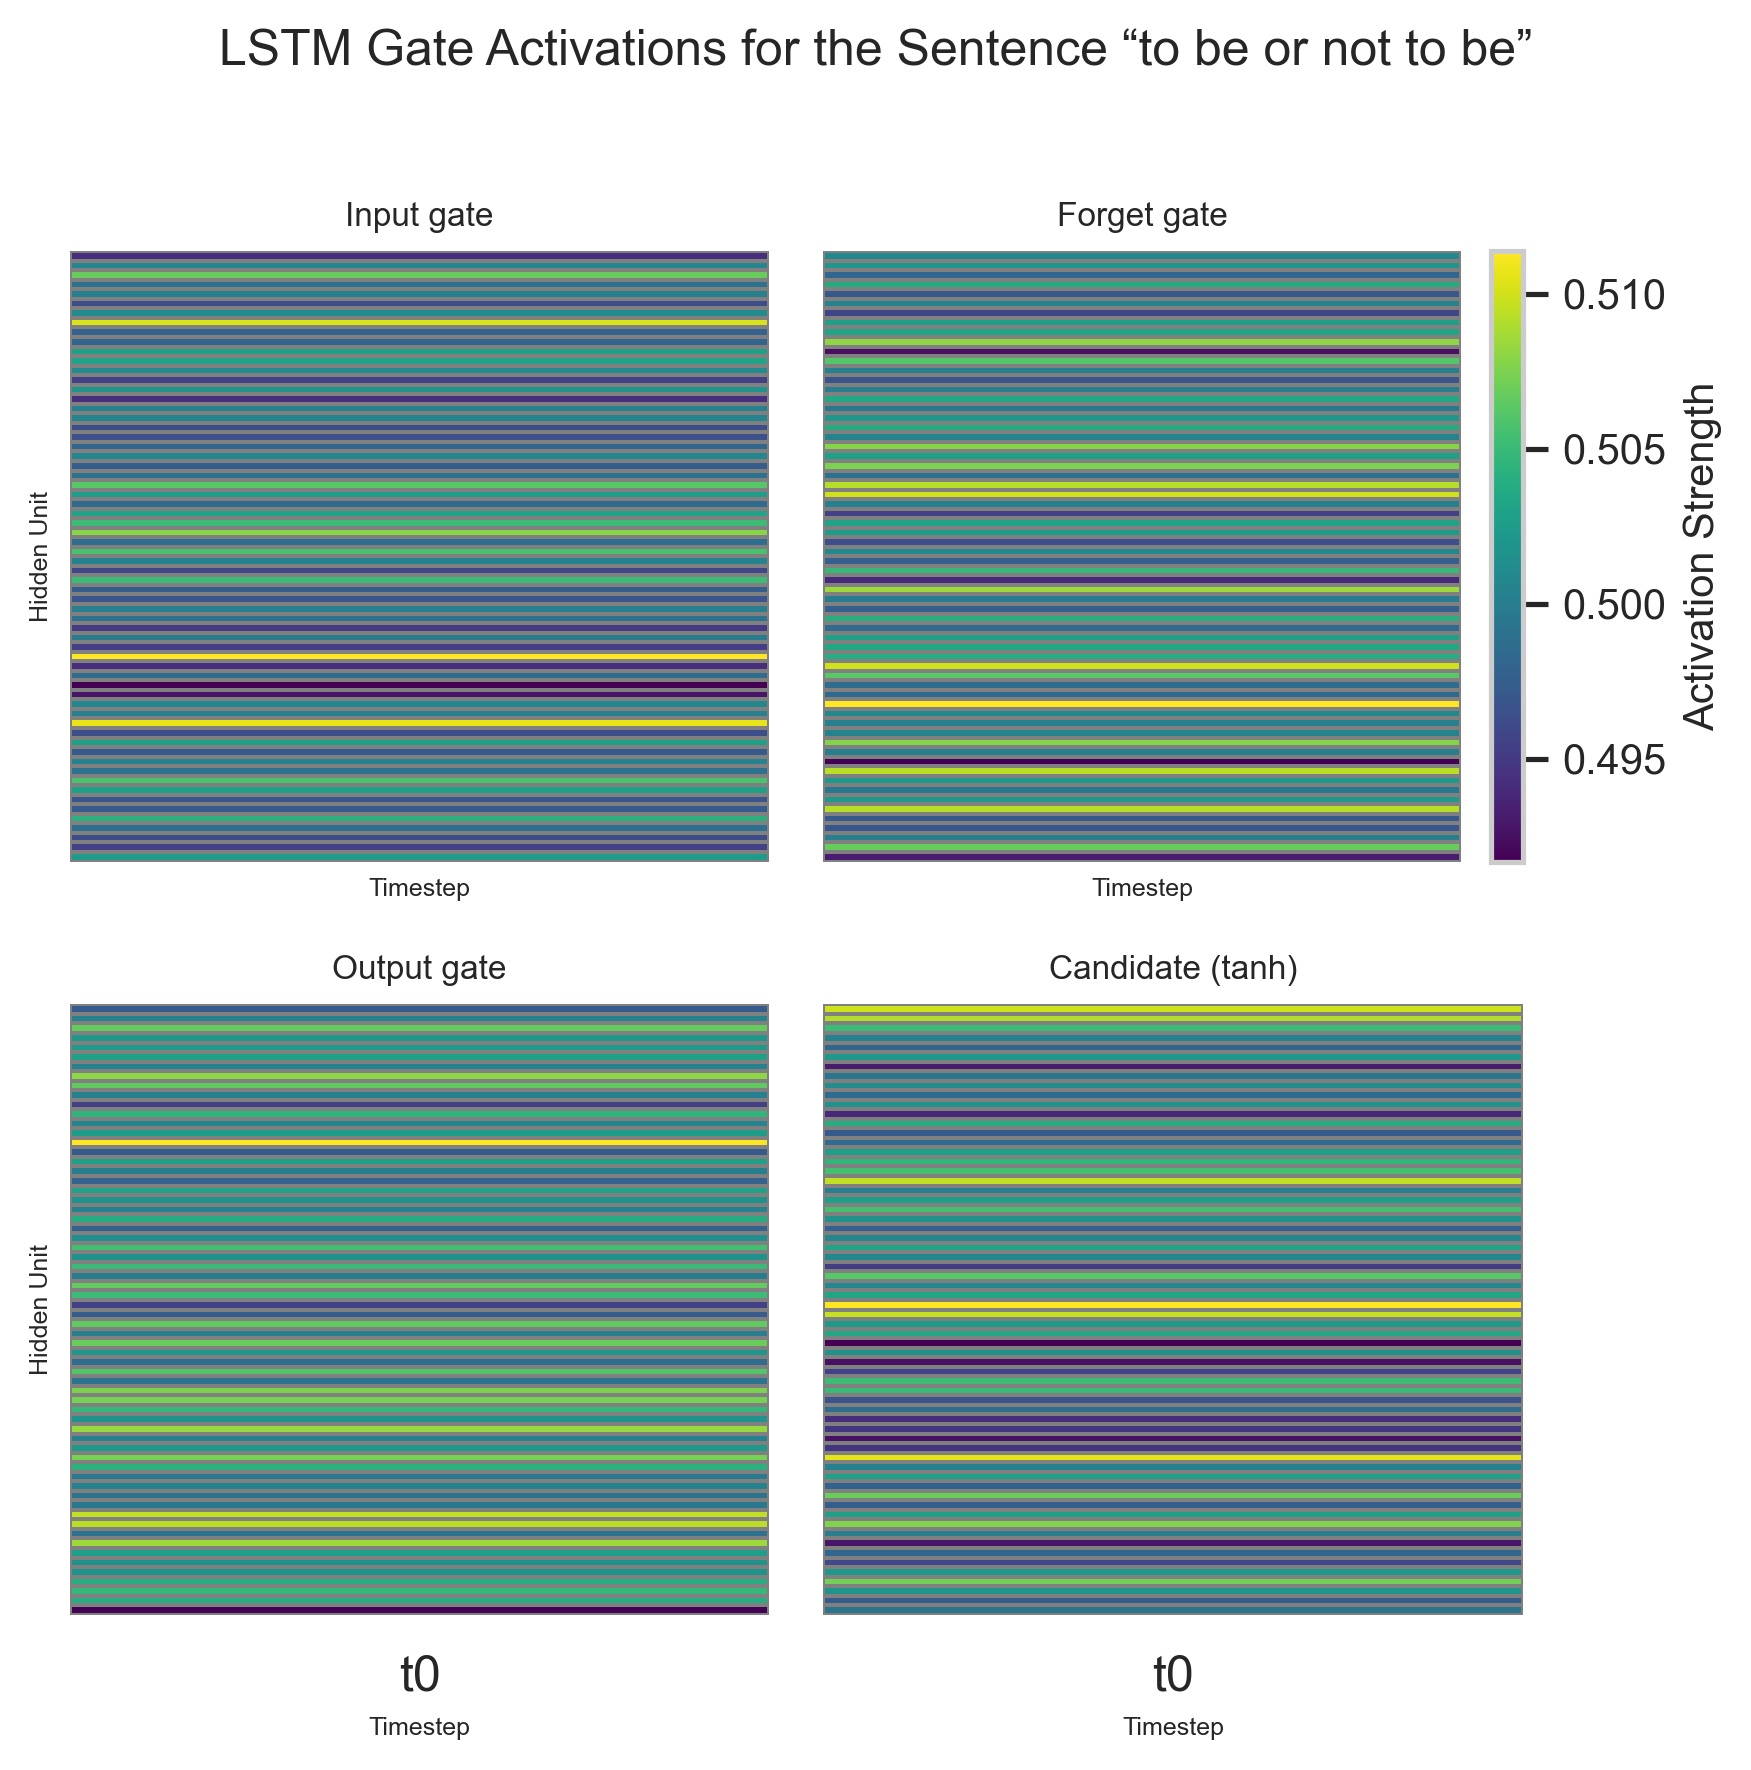

In [81]:
fig = create_lstm_gate_heatmaps(gates)
plt.show()